# Марковский процесс принятия решений

В данной работе рассматриваются методы, разработанные для решения Марковских процессов принятия решений, **M**arkov **D**ecision **P**rocesses, **MDP**. В самом широком смысле, MDP определяется тем, как он изменяет состояния и как вычисляются награды.

Переход состояний определяется распределением $P(s' |s,a)$ &mdash; насколько вероятно перейти в состояние $s'$, если производится действие $a$ в состоянии $s$. Существует несколько способов определить функцию вознаграждений, однако ради удобства будет использована следующая сигнатура: $r(s,a,s')$.

_Данный ноутбук вдохновлён заданием из курса_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _от Калифорнийского университета в Беркли_

# Упражнения <span style="color: green">  (2 балла + 2 балла дополнительно) </span>

## **Постановка задачи**  
Рассмотрим оператор $T: \mathbb{R}^{|\mathbb{S}|} \rightarrow \mathbb{R}^{|\mathbb{S}|}$
$$
(T V)(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V(s')],
$$ являющийся сжимающим отображением в норме $\|\cdot\|_\infty$.  
Алгоритм **Value Iteration (VI)** порождает последовательность итераций:  
$$
V_0 \in \mathbb{R}^n, \quad V_{t+1} = T(V_t), \quad \forall t \geq 0.
$$  
Необходимо доказать следующие утверждения.  


## Упражнение 1. Оценка ошибки и сходимости <span style="color: green"> (1 балл) </span>
Докажите, что из неравенства:
$$
\| V_t - V_{t+1} \|_\infty \leq \epsilon (1 - \gamma)(2\gamma)^{-1}
$$
следует, что:
$$
\| V^{\pi_t} - V^* \|_\infty \leq \epsilon.
$$
Здесь $\pi_t$ - жадная политика, полученная из $Q_t$.

**Доказательство.** Обозначим
$$
\delta_t := \|V_{t+1} - V_t\|_\infty = \|T V_t - V_t\|_\infty.
$$
Так как политика $\pi_t$ жадная по отношению к $V_t$, выполняется равенство
$$
T_{\pi_t} V_t = T V_t = V_{t+1},
$$
где $T_{\pi}$ — оператор Беллмана для фиксированной политики $\pi$.

Сначала оценим расстояние от $V_t$ до оптимальной функции ценности $V^*$. Так как $V^* = T V^*$, имеем
$$
\|V^* - V_t\|_\infty = \|T V^* - V_t\|_\infty \le \|T V^* - T V_t\|_\infty + \|T V_t - V_t\|_\infty.
$$
Поскольку $T$ является $\gamma$-сжатием в норме $\|\cdot\|_\infty$, получаем
$$
\|V^* - V_t\|_\infty \le \gamma \|V^* - V_t\|_\infty + \delta_t.
$$
Следовательно,
$$
(1-\gamma)\|V^* - V_t\|_\infty \le \delta_t,
\qquad
\|V^* - V_t\|_\infty \le \frac{\delta_t}{1-\gamma}.
$$

Теперь аналогично оценим расстояние от $V_t$ до $V^{\pi_t}$. Так как $V^{\pi_t} = T_{\pi_t}V^{\pi_t}$, то
$$
\|V^{\pi_t} - V_t\|_\infty = \|T_{\pi_t}V^{\pi_t} - V_t\|_\infty
\le \|T_{\pi_t}V^{\pi_t} - T_{\pi_t}V_t\|_\infty + \|T_{\pi_t}V_t - V_t\|_\infty.
$$
Оператор $T_{\pi_t}$ тоже является $\gamma$-сжатием, а $T_{\pi_t}V_t = TV_t$, поэтому
$$
\|V^{\pi_t} - V_t\|_\infty \le \gamma \|V^{\pi_t} - V_t\|_\infty + \delta_t.
$$
Отсюда
$$
\|V^{\pi_t} - V_t\|_\infty \le \frac{\delta_t}{1-\gamma}.
$$

Теперь распишем разность между $V^*$ и $V^{\pi_t}$:
$$
V^* - V^{\pi_t} = T V^* - T_{\pi_t}V^{\pi_t}
= \bigl(TV^* - T_{\pi_t}V_t\bigr) + \bigl(T_{\pi_t}V_t - T_{\pi_t}V^{\pi_t}\bigr).
$$
Но $T_{\pi_t}V_t = T V_t$, так что
$$
\|V^* - V^{\pi_t}\|_\infty
\le \|TV^* - TV_t\|_\infty + \|T_{\pi_t}V_t - T_{\pi_t}V^{\pi_t}\|_\infty.
$$
Применяя свойство сжатия для $T$ и $T_{\pi_t}$, получаем
$$
\|V^* - V^{\pi_t}\|_\infty
\le \gamma \|V^* - V_t\|_\infty + \gamma \|V_t - V^{\pi_t}\|_\infty.
$$
Подставляя две полученные выше оценки,
$$
\|V^* - V^{\pi_t}\|_\infty
\le \gamma \cdot \frac{\delta_t}{1-\gamma} + \gamma \cdot \frac{\delta_t}{1-\gamma}
= \frac{2\gamma}{1-\gamma}\,\delta_t.
$$
Если теперь
$$
\delta_t = \|V_t - V_{t+1}\|_\infty \le \epsilon \frac{1-\gamma}{2\gamma},
$$
то немедленно следует
$$
\|V^{\pi_t} - V^*\|_\infty \le \epsilon.
$$
Что и требовалось доказать.

## Упражнение 2. Неравенства на оператор $T$ <span style="color: green"> (1 балл) </span>
Докажите, что для любого $v, w \in \mathbb{R}^n$ выполняются следующие неравенства:

1. **Сильная монотонность оператора $ I - T $**:
   $$
   (1 - \gamma) \cdot \| v - w \|_\infty \leq \| (I - T)(v) - (I - T)(w) \|_\infty.
   $$
   
2. **Липшицевость (гладкость) оператора $ I - T $**:
   $$
   \| (I - T)(v) - (I - T)(w) \|_\infty \leq (1 + \gamma) \cdot \| v - w \|_\infty.
   $$

Тут $I$ - тождественный оператор. Эти неравенства аналогичны условиям $\mu$-сильной выпуклости и $L$-Липшицевости градиента для гладких выпуклых функций.

**Доказательство.** Рассмотрим разность:
$$
(I-T)(v) - (I-T)(w) = (v-w) - (Tv - Tw).
$$
Далее используем только два факта:

1. оператор $T$ является $\gamma$-сжатием в норме $\|\cdot\|_\infty$,
$$
\|Tv - Tw\|_\infty \le \gamma \|v-w\|_\infty;
$$

2. для любой нормы выполнены прямое и обратное неравенства треугольника:
$$
\|x+y\| \le \|x\| + \|y\|,
\qquad
\|x-y\| \ge \bigl|\|x\| - \|y\|\bigr|.
$$

**1. Сильная монотонность.** По обратному неравенству треугольника
$$
\|(I-T)(v) - (I-T)(w)\|_\infty
= \|(v-w) - (Tv-Tw)\|_\infty
\ge \|v-w\|_\infty - \|Tv-Tw\|_\infty.
$$
Теперь применяем сжимаемость $T$:
$$
\|(I-T)(v) - (I-T)(w)\|_\infty
\ge \|v-w\|_\infty - \gamma \|v-w\|_\infty
= (1-\gamma)\|v-w\|_\infty.
$$
Первое неравенство доказано.

**2. Липшицевость.** По обычному неравенству треугольника
$$
\|(I-T)(v) - (I-T)(w)\|_\infty
= \|(v-w) - (Tv-Tw)\|_\infty
\le \|v-w\|_\infty + \|Tv-Tw\|_\infty.
$$
Снова используя сжимаемость $T$, получаем
$$
\|(I-T)(v) - (I-T)(w)\|_\infty
\le \|v-w\|_\infty + \gamma \|v-w\|_\infty
= (1+\gamma)\|v-w\|_\infty.
$$
Второе неравенство доказано.

Итак,
$$
(1-\gamma)\|v-w\|_\infty
\le \|(I-T)(v) - (I-T)(w)\|_\infty
\le (1+\gamma)\|v-w\|_\infty.
$$
То есть оператор $I-T$ одновременно ограничен снизу и сверху константами, зависящими только от $\gamma$.

##  Дополнительное упражнение 3. Оценка вычислительной сложности <span style="color: green"> (2 балла) </span>
Докажите, что для получения $\epsilon$-оптимальной политики $\pi$ (то есть такой, что $\| V^\pi - V^* \|_\infty \leq \epsilon$),  
алгоритму Value Iteration требуется выполнить:
$$
O\left( (1 - \gamma)^{-1} \log(\epsilon^{-1} (1 - \gamma)^{-1}) \right)
$$
итераций. 

**Доказательство.** Ниже считаем, что награды равномерно ограничены: $|r(s,a,s')| \le R_{\max}$. В формуле big-O множитель $R_{\max}$ можно скрыть; если дополнительно $R_{\max}=1$, получаем именно запись из условия.

Пусть $V_{t+1}=TV_t$, $V_0=0$, а $\pi_t$ — жадная политика по $V_t$. Из упражнения 1 мы уже знаем: если
$$
\|V_{t+1}-V_t\|_\infty \le \epsilon \frac{1-\gamma}{2\gamma},
$$
то политика $\pi_t$ является $\epsilon$-оптимальной.
Значит, остаётся понять, сколько итераций нужно, чтобы сделать малой величину
$$
\delta_t := \|V_{t+1}-V_t\|_\infty.
$$

Так как $V_{t+1}=TV_t$ и $V_t=TV_{t-1}$, а $T$ — $\gamma$-сжатие, имеем
$$
\delta_t = \|TV_t - TV_{t-1}\|_\infty \le \gamma \|V_t - V_{t-1}\|_\infty = \gamma \delta_{t-1}.
$$
Следовательно,
$$
\delta_t \le \gamma^t \delta_0.
$$

Оценим теперь $\delta_0$:
$$
\delta_0 = \|V_1 - V_0\|_\infty = \|TV_0 - V_0\|_\infty.
$$
Так как $V_0=0$, то
$$
(TV_0)(s) = \max_a \sum_{s'} P(s'|s,a) r(s,a,s'),
$$
поэтому
$$
\delta_0 \le R_{\max}.
$$
Значит,
$$
\delta_t \le \gamma^t R_{\max}.
$$

Чтобы получить $\epsilon$-оптимальную политику, достаточно потребовать
$$
\gamma^t R_{\max} \le \epsilon \frac{1-\gamma}{2\gamma}.
$$
Отсюда
$$
\gamma^t \le \frac{\epsilon(1-\gamma)}{2\gamma R_{\max}}.
$$
Логарифмируя,
$$
t \ge \frac{\log \left(\frac{2\gamma R_{\max}}{\epsilon(1-\gamma)}\right)}{\log(1/\gamma)}.
$$

Остаётся использовать стандартную оценку
$$
\log(1/\gamma) \asymp 1-\gamma \quad \text{при } \gamma \uparrow 1,
$$
а точнее, например,
$$
\log(1/\gamma) \ge 1-\gamma.
$$
Тогда
$$
t = O\left(\frac{1}{1-\gamma} \log \frac{R_{\max}}{\epsilon(1-\gamma)}\right).
$$
Если $R_{\max}=1$ или этот множитель прячется в константе big-O, получаем
$$
t = O\left((1-\gamma)^{-1} \log\bigl(\epsilon^{-1}(1-\gamma)^{-1}\bigr)\right).
$$
Что и требовалось доказать.

**Замечание.** Из этой оценки видно, что основная трудность возникает при $\gamma \to 1$: число итераций растёт как минимум пропорционально $(1-\gamma)^{-1}$, то есть при большом горизонте дисконтирования обычный Value Iteration неизбежно замедляется.

# Итерационная оптимизация ценности, Value Iteration <span style="color: green"> (2 балла) </span>


In [1]:
import numpy as np
from numpy import random
from time import sleep
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
%matplotlib inline

from mdp import MDP, FrozenLakeEnv, has_graphviz, plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values

Для начала, давайте определим простой MDP, изображённый на рисунке ниже:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

Теперь можно использовать MDP как и другие среды от Open AI Gym:

In [3]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


но также есть и другие методы, необходимые для имплементации алгоритма итерацонной оптимизации ценности (Value Iteration)

In [4]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ",
      mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Опционально: визуализация MDP

Вы можете визуализировать MDP с помощью функции отрисовки, написанной [neer201](https://github.com/neer201).

Для этого требуется установить graphviz системно и для Python. На Unix-подобных системах (Ubuntu) для этого достатчно выполнить следующие команды:

1. `sudo apt-get install graphviz`
2. `pip install graphviz`
3. перезагрузить этот ноутбук

__Замечание:__ Установка graphviz на некоторые ОС (особенно Windows) может быть нетривиальной. Поэтому можно пропусить данный шаг и использовать стандартную визуализацию.

In [5]:
print("Graphviz доступен:", has_graphviz)

Graphviz доступен: True


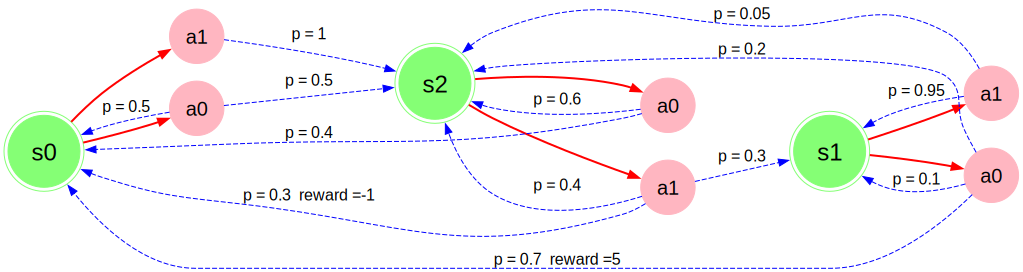

In [6]:
if has_graphviz:
    display(plot_graph(mdp))

Теперь построим первый способ решения MDP. Простейший на данный момент алгоритм называется итерационной оптимизацией ценности или **V**alue **I**teration

Ниже представлен псевдокод **VI**:

---

`1.` Инициализация $V^{(0)}(s)=0$, for all $s$

`2.` Для $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, для всех $s$

---

Для начала выпишем функцию вычисления $Q$-функции ценности $Q^{\pi}$, определив следующим образом

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [7]:
%%writefile mdp_get_action_value.py
def get_action_value(mdp, state_values, state, action, gamma):
    """ Вычисляет Q(s,a) согласно формуле выше """
    q_value = 0.0
    for next_state, prob in mdp.get_next_states(state, action).items():
        reward = mdp.get_reward(state, action, next_state)
        q_value += prob * (reward + gamma * state_values[next_state])
    return q_value

Overwriting mdp_get_action_value.py


In [8]:
from mdp_get_action_value import *

In [9]:
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Используя $Q(s,a)$ можно определить "следующее" $V(s)$ для итерационной оптимизации ценности.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [10]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Вычисляет следующее V(s) согласно формуле выше. Просьба не изменять state_values в процессе. """
    if mdp.is_terminal(state):
        return 0

    q_values = [get_action_value(mdp, state_values, state, action, gamma)
                for action in mdp.get_possible_actions(state)]
    return max(q_values)

In [11]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert test_Vs == test_Vs_copy, "просьба не изменять state_values в get_new_state_value"

Наконец-то можно скомбинировать написанное в работающий алгоритм.

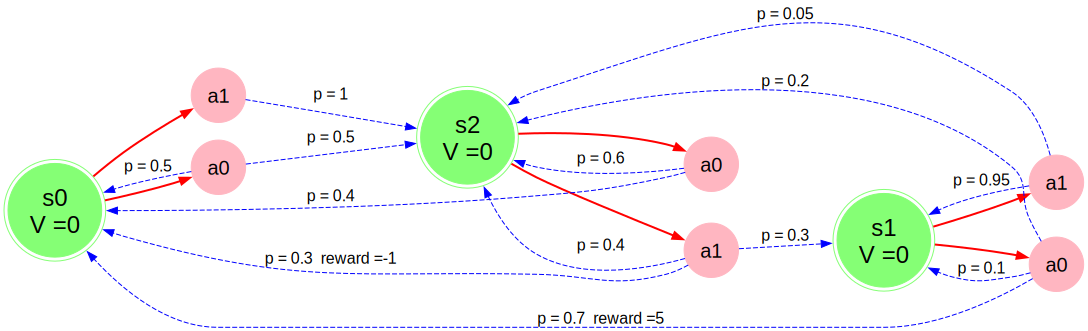

Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
Итерация    1   |   разность max_s|V_new(s) - V_old(s)|: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
Итерация    2   |   разность max_s|V_new(s) - V_old(s)|: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
Итерация    3   |   разность max_s|V_new(s) - V_old(s)|: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
Итерация    4   |   разность max_s|V_new(s) - V_old(s)|: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
Итерация    5   |   разность max_s|V_new(s) - V_old(s)|: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
Итерация    6   |   разность max_s|V_new(s) - V_old(s)|: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
Итерация    7   |   разность max_s|V_new(s) - V_old(s)|: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
Итерация    8   |   разность max_s|V_new(s) - V_old(s)|: 0.19277

In [12]:
%%time

# гиперпараметры
gamma = 0.9            # фактор дисконтирования MDP
num_iter = 100         # максимальное количество итераций, не включая инициализацию
# останов VI, если новые значения V(s) настолько близки к старым (или ближе)
min_difference = 0.001

# инициализация V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Вычисление новых V(s) используя определённые выше функции.
    # Должен быть словарь {state : float V_new(state)}
    new_state_values = {
        state: get_new_state_value(mdp, state_values, state, gamma)
        for state in mdp.get_all_states()
    }

    assert isinstance(new_state_values, dict)

    # Вычисление темпоральных различий V(s)
    diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())
    print("Итерация %4i   |   разность max_s|V_new(s) - V_old(s)|: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Останов")
        break

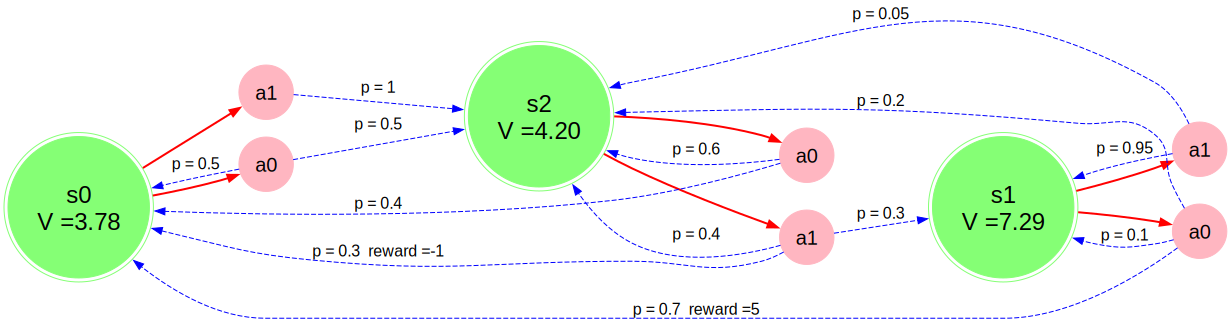

In [13]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [14]:
print("Финальные ценности состояний:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Финальные ценности состояний: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


Теперь используем полученные $V^{*}(s)$ для определения оптимальных действий в каждом состоянии

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
Единственное отличие по сравнению с вычислением `V(s)` состоит в извлечении не `max`, а `argmax`: поиск действия с максимальной ценностью `Q(s,a)`.

In [15]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """ Выбор оптимального действия, используя формулу выше. """
    if mdp.is_terminal(state):
        return None

    actions = mdp.get_possible_actions(state)
    return max(actions, key=lambda action: get_action_value(mdp, state_values, state, action, gamma))

In [16]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

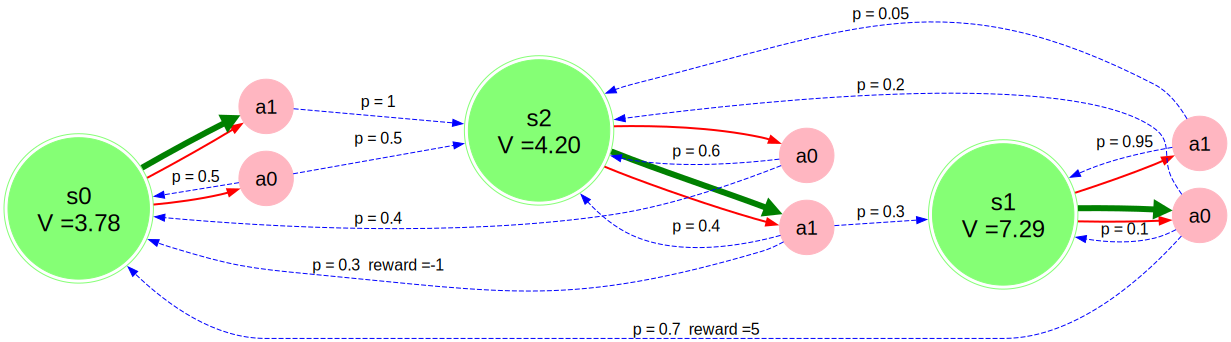

In [17]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values))

In [18]:
%%time

# Оценка средней награды агента

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("средняя награда: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

средняя награда:  0.4817
CPU times: user 191 ms, sys: 15.7 ms, total: 207 ms
Wall time: 220 ms


# Ускоренная итерационная оптимизация ценности, Momentum Value Iteration <span style="color: green"> (2 балла) </span>

Аналогично оптимизации, в RL также есть различные техники ускорения поиска решения (оптимума). Momentum Value Iteration - один из них (см. [тут](https://arxiv.org/pdf/1905.09963)).  

---

**Algorithm M-VI:**

**Input:**  
- Начальные значения $ v_0 $, $v_1 = T(v^{(0)}) \in \mathbb{R}^{|\mathbf{S}|} $  
- Шаги спуска $ (\alpha_t)_{t \geq 0} $  
- Коэффициенты момента $ (\beta_t)_{t \geq 0} $ 

**For** $ t = 1, 2, 3, \dots $ **do**  
1. Обновляем значения:  
   $
   v_{t+1} = v_t - \alpha_t (v_t - T(v_t)) + \beta_t \cdot (v_t - v_{t-1})
   $  
**End For**

---

In [19]:
#имплементируйте шаг алгоритма
def momentum_step(mdp, prev_state_values, curr_state_values, state, gamma, alpha, beta):
    
    #примените оператор Беллмана к v_t
    T_v = get_new_state_value(mdp, curr_state_values, state, gamma)
    
    #реализуйте шаг алгоритма
    v_next = curr_state_values[state] - alpha * (curr_state_values[state] - T_v) + beta * (curr_state_values[state] - prev_state_values[state])
    return v_next

## Hard instance MDP
Существует класс так называемых hard instance MDPs - MDP, решение уравнения Беллмана для которых сложно найти с хорошей точностью. Один из них - ForestMDP

In [20]:
transition_probs = {}

n = 5  # Example value for the maximum forest age
p = 0.05  # Probability of wildfire

transition_probs['s0'] = {'wait': {'s1': 1.0}, 'cut_sell': {'s1': 1.0}}

for i in range(1, n):
    transition_probs[f's{i}'] = {
        'wait': {f's{i+1}': 1 - p, 's1': p},
        'cut_sell': {'s1': 1.0}
    }

# Last state (forest cannot grow beyond n)
transition_probs[f's{n}'] = {
    'wait': {f's{n}': 1 - p, 's1': p},
    'cut_sell': {'s1': 1.0}
}

rewards = {}

rewards['s0'] = {'wait': {'s1': 0}, 'cut_sell': {'s1': 0}}

for i in range(1, n):
    rewards[f's{i}'] = {
        'wait': {f's{i+1}': 0, 's1': 0},
        'cut_sell': {'s1': 1 if i < n else 2}
    }

# Last state has a reward for waiting
rewards[f's{n}'] = {
    'wait': {f's{n}': 4, 's1': 0},
    'cut_sell': {'s1': 2}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

Постройте графики сравнений сходимости алгоритмов обычного Value Iteration и Momentum Value Iteration в терминах числа итераций, а также затрачиваемого времени на их работу при разных значениях $\gamma$. В качестве критерия сходимости используйте $\|V_{t+1} - V_t\|_{\infty}$. Является ли эта зависимость монотонной? Сделайте выводы

gamma=0.10: VI -> 10 ит., 0.000290 c | MVI -> 9 ит., 0.000268 c | alpha=1.0025, beta=0.0025
gamma=0.30: VI -> 17 ит., 0.000482 c | MVI -> 13 ит., 0.000399 c | alpha=1.0236, beta=0.0236
gamma=0.50: VI -> 29 ит., 0.000826 c | MVI -> 18 ит., 0.000588 c | alpha=1.0718, beta=0.0718
gamma=0.70: VI -> 54 ит., 0.001556 c | MVI -> 30 ит., 0.000947 c | alpha=1.1668, beta=0.1668
gamma=0.80: VI -> 89 ит., 0.002489 c | MVI -> 47 ит., 0.001509 c | alpha=1.2500, beta=0.2500
gamma=0.90: VI -> 187 ит., 0.005784 c | MVI -> 73 ит., 0.002354 c | alpha=1.3929, beta=0.3929
gamma=0.95: VI -> 382 ит., 0.010506 c | MVI -> 111 ит., 0.003599 c | alpha=1.5241, beta=0.5241


gamma=0.99: VI -> 1947 ит., 0.054172 c | MVI -> 10000 ит., 0.328071 c | alpha=1.7527, beta=0.7527


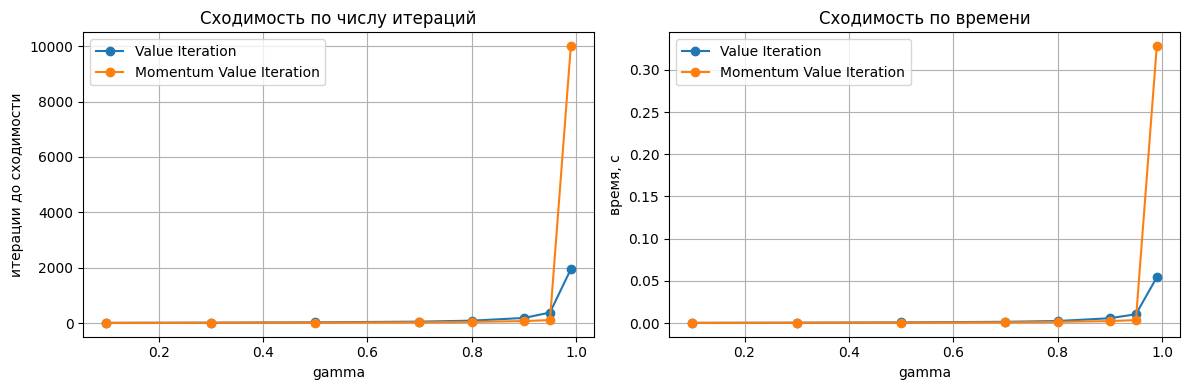

Вывод: в целом с ростом gamma оба алгоритма замедляются, но зависимость по времени не обязана быть строго монотонной из-за накладных расходов интерпретатора и небольшого размера MDP. По числу итераций тренд обычно близок к монотонному.


In [21]:
from time import perf_counter


def run_vi(mdp, gamma, tol=1e-8, max_iter=10000):
    state_values = {s: 0.0 for s in mdp.get_all_states()}
    start = perf_counter()
    for iteration in range(1, max_iter + 1):
        new_state_values = {
            state: get_new_state_value(mdp, state_values, state, gamma)
            for state in mdp.get_all_states()
        }
        diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())
        state_values = new_state_values
        if diff < tol:
            return iteration, perf_counter() - start, diff
    return max_iter, perf_counter() - start, diff


def run_mvi(mdp, gamma, tol=1e-8, max_iter=10000):
    mu = 1 - gamma
    L = 1 + gamma
    alpha = 4.0 / (np.sqrt(L) + np.sqrt(mu)) ** 2
    beta = ((np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))) ** 2

    prev_state_values = {s: 0.0 for s in mdp.get_all_states()}
    curr_state_values = {
        state: get_new_state_value(mdp, prev_state_values, state, gamma)
        for state in mdp.get_all_states()
    }

    start = perf_counter()
    diff = max(abs(curr_state_values[s] - prev_state_values[s]) for s in mdp.get_all_states())
    if diff < tol:
        return 1, perf_counter() - start, diff, alpha, beta

    for iteration in range(2, max_iter + 1):
        next_state_values = {
            state: momentum_step(mdp, prev_state_values, curr_state_values, state, gamma, alpha, beta)
            for state in mdp.get_all_states()
        }
        diff = max(abs(next_state_values[s] - curr_state_values[s]) for s in mdp.get_all_states())
        prev_state_values, curr_state_values = curr_state_values, next_state_values
        if diff < tol:
            return iteration, perf_counter() - start, diff, alpha, beta
    return max_iter, perf_counter() - start, diff, alpha, beta


gammas = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
vi_iters, vi_times = [], []
mvi_iters, mvi_times = [], []

for gamma_value in gammas:
    vi_iter, vi_time, _ = run_vi(mdp, gamma_value)
    mvi_iter, mvi_time, _, alpha, beta = run_mvi(mdp, gamma_value)
    vi_iters.append(vi_iter)
    vi_times.append(vi_time)
    mvi_iters.append(mvi_iter)
    mvi_times.append(mvi_time)
    print(f'gamma={gamma_value:.2f}: VI -> {vi_iter} ит., {vi_time:.6f} c | MVI -> {mvi_iter} ит., {mvi_time:.6f} c | alpha={alpha:.4f}, beta={beta:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gammas, vi_iters, marker='o', label='Value Iteration')
axes[0].plot(gammas, mvi_iters, marker='o', label='Momentum Value Iteration')
axes[0].set_title('Сходимость по числу итераций')
axes[0].set_xlabel('gamma')
axes[0].set_ylabel('итерации до сходимости')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(gammas, vi_times, marker='o', label='Value Iteration')
axes[1].plot(gammas, mvi_times, marker='o', label='Momentum Value Iteration')
axes[1].set_title('Сходимость по времени')
axes[1].set_xlabel('gamma')
axes[1].set_ylabel('время, c')
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()

print('Вывод: в целом с ростом gamma оба алгоритма замедляются, но зависимость по времени не обязана быть строго монотонной из-за накладных расходов интерпретатора и небольшого размера MDP. По числу итераций тренд обычно близок к монотонному.')

### Frozen lake

In [22]:
mdp = FrozenLakeEnv(slip_chance=0)
mdp.render()

*FFF
FHFH
FFFH
HFFG



In [23]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5, verbose=True):
    """ Выполняет num_iter шагов итерационной оптимизации ценности, начиная с state_values.
         То же, что и ранее, но в формате функции """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Вычислить новые ценности состояний, используя определённые выше функции.
        # В результате должен получиться словарь формата {state : new_V(state)}
        new_state_values = {
            state: get_new_state_value(mdp, state_values, state, gamma)
            for state in mdp.get_all_states()
        }

        assert isinstance(new_state_values, dict)

        # Вычислить темпоральную разность по значениям ценности
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())
        
        if verbose:
            print("Итерация %4i   |   разность max_s|V_new(s) - V_old(s)|: %6.5f   |   V(start): %.3f " %
                  (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [24]:
%%time

state_values = value_iteration(mdp)

Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 1.00000   |   V(start): 0.000 
Итерация    1   |   разность max_s|V_new(s) - V_old(s)|: 0.90000   |   V(start): 0.000 
Итерация    2   |   разность max_s|V_new(s) - V_old(s)|: 0.81000   |   V(start): 0.000 
Итерация    3   |   разность max_s|V_new(s) - V_old(s)|: 0.72900   |   V(start): 0.000 
Итерация    4   |   разность max_s|V_new(s) - V_old(s)|: 0.65610   |   V(start): 0.000 
Итерация    5   |   разность max_s|V_new(s) - V_old(s)|: 0.59049   |   V(start): 0.590 
Итерация    6   |   разность max_s|V_new(s) - V_old(s)|: 0.00000   |   V(start): 0.590 
CPU times: user 653 μs, sys: 5 μs, total: 658 μs
Wall time: 657 μs


In [25]:
%%time

s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*

CPU times: user 356 μs, sys: 34 μs, total: 390 μs
Wall time: 366 μs


### Время визуализаций!

Обычно полезно и интересно видеть, что в действительности Ваш алгоритм выучивает под капотом. Для этого можно изобразить V-функцию и оптимальные действия на каждом шаге алгоритма VI.

In [26]:
def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (-1, 0)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

после итерации 0
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 1.00000   |   V(start): 0.000 


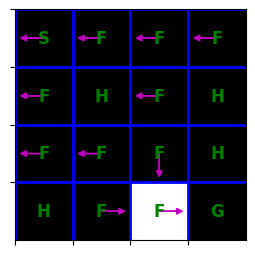

после итерации 1
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.90000   |   V(start): 0.000 


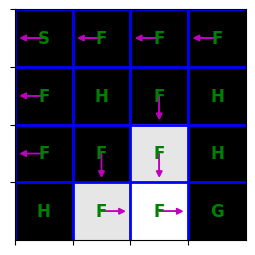

после итерации 2
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.81000   |   V(start): 0.000 


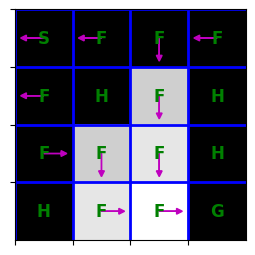

после итерации 3
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.72900   |   V(start): 0.000 


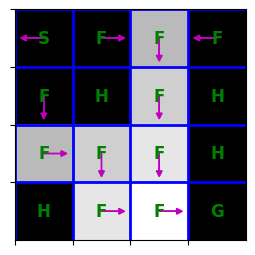

после итерации 4
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.65610   |   V(start): 0.000 


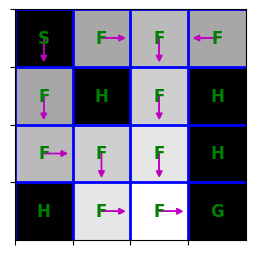

после итерации 5
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.59049   |   V(start): 0.590 


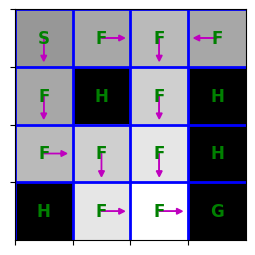

после итерации 6
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.00000   |   V(start): 0.590 


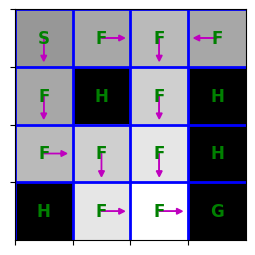

после итерации 7
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.00000   |   V(start): 0.590 


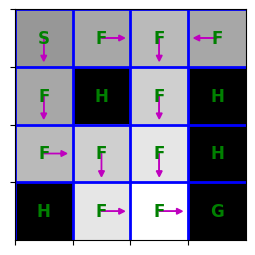

после итерации 8
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.00000   |   V(start): 0.590 


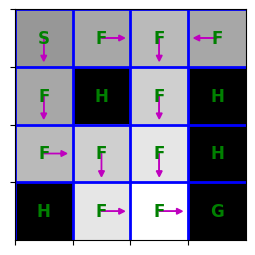

после итерации 9
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.00000   |   V(start): 0.590 


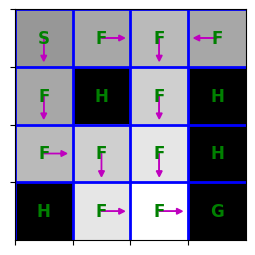

CPU times: user 441 ms, sys: 20.3 ms, total: 461 ms
Wall time: 471 ms


In [27]:
%%time

state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("после итерации %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# просьба игнорировать отладочный вывод "Итерация 0" на каждом шаге

после итерации 29
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.00000   |   V(start): 0.198 


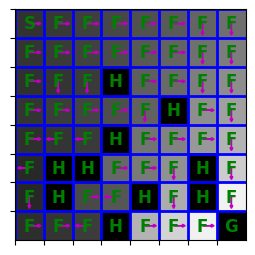

CPU times: user 3.35 s, sys: 106 ms, total: 3.46 s
Wall time: 18.6 s


In [28]:
%%time

mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("после итерации %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# просьба игнорировать отладочный вывод "Итерация 0" на каждом шаге

Массовые испытания

In [29]:
%%time

mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("средняя награда: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Отлинчая работа!")

Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 1.00000   |   V(start): 0.000 
Итерация    1   |   разность max_s|V_new(s) - V_old(s)|: 0.90000   |   V(start): 0.000 
Итерация    2   |   разность max_s|V_new(s) - V_old(s)|: 0.81000   |   V(start): 0.000 
Итерация    3   |   разность max_s|V_new(s) - V_old(s)|: 0.72900   |   V(start): 0.000 
Итерация    4   |   разность max_s|V_new(s) - V_old(s)|: 0.65610   |   V(start): 0.000 
Итерация    5   |   разность max_s|V_new(s) - V_old(s)|: 0.59049   |   V(start): 0.590 
Итерация    6   |   разность max_s|V_new(s) - V_old(s)|: 0.00000   |   V(start): 0.590 
средняя награда:  1.0
Отлинчая работа!
CPU times: user 137 ms, sys: 22.3 ms, total: 159 ms
Wall time: 139 ms


In [30]:
%%time

# Оценка средней награды агента
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("средняя награда: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Отличная работа!")

Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.90000   |   V(start): 0.000 
Итерация    1   |   разность max_s|V_new(s) - V_old(s)|: 0.72900   |   V(start): 0.000 
Итерация    2   |   разность max_s|V_new(s) - V_old(s)|: 0.62330   |   V(start): 0.000 
Итерация    3   |   разность max_s|V_new(s) - V_old(s)|: 0.50487   |   V(start): 0.000 
Итерация    4   |   разность max_s|V_new(s) - V_old(s)|: 0.40894   |   V(start): 0.000 
Итерация    5   |   разность max_s|V_new(s) - V_old(s)|: 0.34868   |   V(start): 0.349 
Итерация    6   |   разность max_s|V_new(s) - V_old(s)|: 0.06529   |   V(start): 0.410 
Итерация    7   |   разность max_s|V_new(s) - V_old(s)|: 0.05832   |   V(start): 0.468 
Итерация    8   |   разность max_s|V_new(s) - V_old(s)|: 0.01139   |   V(start): 0.480 
Итерация    9   |   разность max_s|V_new(s) - V_old(s)|: 0.00764   |   V(start): 0.487 
Итерация   10   |   разность max_s|V_new(s) - V_old(s)|: 0.00164   |   V(start): 0.489 
Итерация   11   |   разность max

средняя награда:  0.868
Отличная работа!
CPU times: user 170 ms, sys: 22.1 ms, total: 192 ms
Wall time: 176 ms


In [31]:
%%time

# Оценка средней награды агента
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("средняя награда: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Отличная работа!")

Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.75000   |   V(start): 0.000 
Итерация    1   |   разность max_s|V_new(s) - V_old(s)|: 0.50625   |   V(start): 0.000 
Итерация    2   |   разность max_s|V_new(s) - V_old(s)|: 0.39867   |   V(start): 0.000 
Итерация    3   |   разность max_s|V_new(s) - V_old(s)|: 0.26910   |   V(start): 0.000 
Итерация    4   |   разность max_s|V_new(s) - V_old(s)|: 0.18164   |   V(start): 0.000 
Итерация    5   |   разность max_s|V_new(s) - V_old(s)|: 0.14013   |   V(start): 0.140 
Итерация    6   |   разность max_s|V_new(s) - V_old(s)|: 0.07028   |   V(start): 0.199 
Итерация    7   |   разность max_s|V_new(s) - V_old(s)|: 0.06030   |   V(start): 0.260 
Итерация    8   |   разность max_s|V_new(s) - V_old(s)|: 0.02594   |   V(start): 0.285 
Итерация    9   |   разность max_s|V_new(s) - V_old(s)|: 0.01918   |   V(start): 0.305 
Итерация   10   |   разность max_s|V_new(s) - V_old(s)|: 0.00858   |   V(start): 0.313 
Итерация   11   |   разность max

средняя награда:  0.635
Отличная работа!
CPU times: user 179 ms, sys: 24.3 ms, total: 203 ms
Wall time: 193 ms


In [32]:
%%time

# Оценка средней награды агента
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("средняя награда: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Отличная работа!")

Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.80000   |   V(start): 0.000 
Итерация    1   |   разность max_s|V_new(s) - V_old(s)|: 0.57600   |   V(start): 0.000 
Итерация    2   |   разность max_s|V_new(s) - V_old(s)|: 0.41472   |   V(start): 0.000 
Итерация    3   |   разность max_s|V_new(s) - V_old(s)|: 0.29860   |   V(start): 0.000 
Итерация    4   |   разность max_s|V_new(s) - V_old(s)|: 0.24186   |   V(start): 0.000 
Итерация    5   |   разность max_s|V_new(s) - V_old(s)|: 0.19349   |   V(start): 0.000 
Итерация    6   |   разность max_s|V_new(s) - V_old(s)|: 0.15325   |   V(start): 0.000 
Итерация    7   |   разность max_s|V_new(s) - V_old(s)|: 0.12288   |   V(start): 0.000 
Итерация    8   |   разность max_s|V_new(s) - V_old(s)|: 0.09930   |   V(start): 0.000 
Итерация    9   |   разность max_s|V_new(s) - V_old(s)|: 0.08037   |   V(start): 0.000 
Итерация   10   |   разность max_s|V_new(s) - V_old(s)|: 0.06426   |   V(start): 0.000 
Итерация   11   |   разность max

средняя награда:  0.73
Отличная работа!
CPU times: user 481 ms, sys: 49.3 ms, total: 531 ms
Wall time: 517 ms


# Итерационная оптимизация политики, Policy Iteration <span style="color: green"> (2 балла) </span>

Требуется имплементировать явную итерационную оптимизацию политики, Policy Iteration (PI) согласно следующему псевдокоду:

---
Инициализация $\pi_0$   `// случайная или константная`

Для $n=0, 1, 2, \dots$
- Вычислить функцию $V^{\pi_{n}}$
- С помощью $V^{\pi_{n}}$, вычислить функцию $Q^{\pi_{n}}$
- Вычислить новую политику $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

В отличие от VI, Policy Iteration требует явное вычисление политики &mdash; выбранное действие для каждого состояния &mdash; и оценку $V^{\pi_{n}}$ на основе данной политики. Обновление политики происходит после (итеративного) вычисления V-функции.


Ниже представлены несколько функций-помощников, которые могут оказаться полезными при имплементации методов.

In [33]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

Настало время написать функцию под названием `compute_vpi`, которая вычисляет функцию $V^{\pi}$ для произвольной политики $\pi$.

В отличие от VI, в этот раз требуется точное решение, не просто одна итерация.

Напоминаем, что $V^{\pi}$ удовлетворяет следующему линейному соотношению:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

Вам потребуется решить систему линейных алгебраических уравнений в коде. (Найдите точное решение, например, С помощью `np.linalg.solve` или метода простых итераций.)

In [34]:
def compute_vpi(mdp, policy, gamma):
    """
    Вычисляет V^pi(s) ДЛЯ ВСЕХ СОСТОЯНИЙ при текущей политике.
    :параметр policy: словарь выбранных на данный момент действий {s : a}
    :возвращает: словарь {state : V^pi(state) для всех state}
    """

    states = list(mdp.get_all_states())
    state_to_idx = {state: i for i, state in enumerate(states)}
    A = np.zeros((len(states), len(states)))
    b = np.zeros(len(states))

    for state in states:
        i = state_to_idx[state]
        A[i, i] = 1.0
        if mdp.is_terminal(state):
            continue

        action = policy[state]
        for next_state, prob in mdp.get_next_states(state, action).items():
            reward = mdp.get_reward(state, action, next_state)
            A[i, state_to_idx[next_state]] -= gamma * prob
            b[i] += prob * reward

    values = np.linalg.solve(A, b)
    return {state: values[state_to_idx[state]] for state in states}

In [35]:
%%time

test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi должен возвращать словарь {state : V^pi(state) для всех state}"

{'s0': np.float64(2.8399699474079645), 's1': np.float64(6.498873027798648), 's2': np.float64(3.471074380165291)}
CPU times: user 199 μs, sys: 306 μs, total: 505 μs
Wall time: 1.7 ms


Как только получены новые ценности состояний, время обновить текущую политику.

In [36]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Вычисляет жадно новую политику как argmax по функции ценности
    :параметр vpi: словарь {state : V^pi(state) для всех state}
    :возвращает: словарь {state : оптимальное действие для всех state}
    """
    return {
        state: get_optimal_action(mdp, vpi, state, gamma)
        for state in mdp.get_all_states()
    }

In [37]:
%%time

new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy должен возвращать словарь {состояние : оптимальное действие}"

{'s0': 'a1', 's1': 'a0', 's2': 'a1'}
CPU times: user 54 μs, sys: 6 μs, total: 60 μs
Wall time: 60.1 μs


__Основной цикл__

In [38]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ 
    Запуск итерационной оптимизации политики в цикле на num_iter итераций, или пока max_s|V_new(s) - V_old(s)|
    не станет меньше min_difference. Если начальная политика не дана, то инициализация случайная.
    """
    states = list(mdp.get_all_states())
    if policy is None:
        policy = {
            state: (None if mdp.is_terminal(state) else np.random.choice(mdp.get_possible_actions(state)))
            for state in states
        }

    state_values = {state: 0.0 for state in states}

    for _ in range(num_iter):
        new_state_values = compute_vpi(mdp, policy, gamma)
        diff = max(abs(new_state_values[state] - state_values[state]) for state in states)
        new_policy = compute_new_policy(mdp, new_state_values, gamma)
        state_values = new_state_values
        policy_stable = new_policy == policy
        policy = new_policy
        if policy_stable or diff < min_difference:
            break
    return state_values, policy

__Ваши результаты экспериментирования с PI__

4x4, slip=0.0: VI -> 7 ит., 0.000565 c | PI -> 1 ит., 0.000178 c
4x4, slip=0.1: VI -> 17 ит., 0.002416 c | PI -> 1 ит., 0.000271 c
4x4, slip=0.25: VI -> 22 ит., 0.003050 c | PI -> 1 ит., 0.000240 c
8x8, slip=0.2: VI -> 34 ит., 0.022571 c | PI -> 9 ит., 0.010095 c


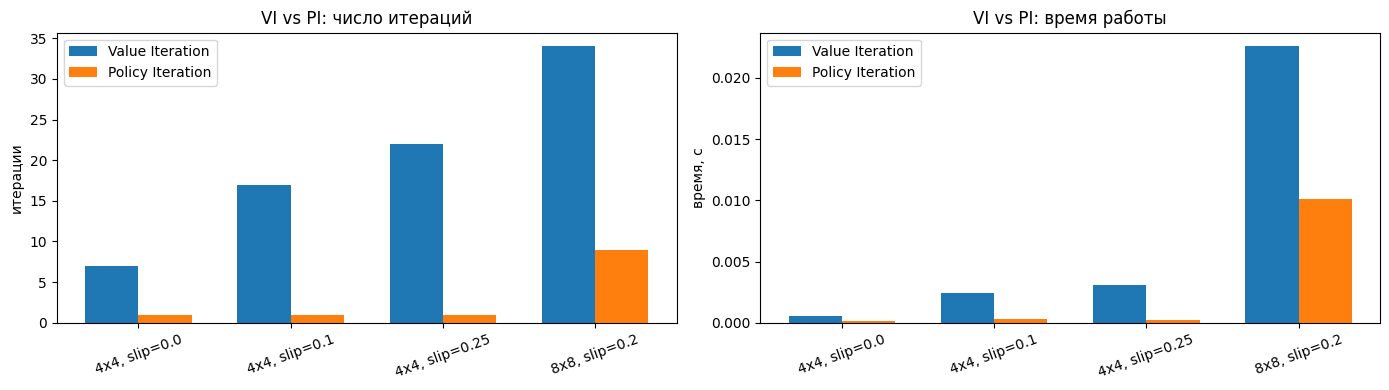

In [39]:
from time import perf_counter


def value_iteration_with_stats(mdp, gamma=0.9, num_iter=1000, min_difference=1e-5):
    state_values = {s: 0.0 for s in mdp.get_all_states()}
    start = perf_counter()
    for iteration in range(1, num_iter + 1):
        new_state_values = {
            state: get_new_state_value(mdp, state_values, state, gamma)
            for state in mdp.get_all_states()
        }
        diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())
        state_values = new_state_values
        if diff < min_difference:
            return state_values, iteration, perf_counter() - start
    return state_values, num_iter, perf_counter() - start


def policy_iteration_with_stats(mdp, gamma=0.9, num_iter=1000, min_difference=1e-5):
    states = list(mdp.get_all_states())
    policy = {
        state: (None if mdp.is_terminal(state) else mdp.get_possible_actions(state)[0])
        for state in states
    }
    prev_values = {state: 0.0 for state in states}
    start = perf_counter()

    for iteration in range(1, num_iter + 1):
        state_values = compute_vpi(mdp, policy, gamma)
        diff = max(abs(state_values[state] - prev_values[state]) for state in states)
        new_policy = compute_new_policy(mdp, state_values, gamma)
        policy_stable = new_policy == policy
        policy = new_policy
        prev_values = state_values
        if policy_stable or diff < min_difference:
            return state_values, policy, iteration, perf_counter() - start

    return state_values, policy, num_iter, perf_counter() - start


experiments = [
    ('4x4, slip=0.0', FrozenLakeEnv(slip_chance=0.0)),
    ('4x4, slip=0.1', FrozenLakeEnv(slip_chance=0.1)),
    ('4x4, slip=0.25', FrozenLakeEnv(slip_chance=0.25)),
    ('8x8, slip=0.2', FrozenLakeEnv(map_name='8x8', slip_chance=0.2)),
]

labels, vi_iters, pi_iters, vi_times, pi_times = [], [], [], [], []
for label, env in experiments:
    _, vi_iter, vi_time = value_iteration_with_stats(env, gamma=gamma)
    _, _, pi_iter, pi_time = policy_iteration_with_stats(env, gamma=gamma)
    labels.append(label)
    vi_iters.append(vi_iter)
    pi_iters.append(pi_iter)
    vi_times.append(vi_time)
    pi_times.append(pi_time)
    print(f'{label}: VI -> {vi_iter} ит., {vi_time:.6f} c | PI -> {pi_iter} ит., {pi_time:.6f} c')

x = np.arange(len(labels))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(x - width / 2, vi_iters, width, label='Value Iteration')
axes[0].bar(x + width / 2, pi_iters, width, label='Policy Iteration')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylabel('итерации')
axes[0].set_title('VI vs PI: число итераций')
axes[0].legend()

axes[1].bar(x - width / 2, vi_times, width, label='Value Iteration')
axes[1].bar(x + width / 2, pi_times, width, label='Policy Iteration')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylabel('время, c')
axes[1].set_title('VI vs PI: время работы')
axes[1].legend()
plt.tight_layout()
plt.show()

# Поиск MDP, на котором Value Iteration работает достаточно долго <span style="color: green"> (2 балла) </span>

Когда запускали Value Iteration на небольшой задаче frozen lake, последняя итерация, на которой изменялась стратегия обучаемой политики, была под номером 6 (или близко к ней) &mdash; то есть Value Iteration находил оптимальную политику на итерации 6 (или близко к ней). Существуют ли какие-либо гарантии на то, что в общем случае поиск оптимальной политики сверху ограничен конечным числом в MDP с негораниченным горизонтом с дисконтированием? Ответ без дополнительных предположений отрицательный, более того, можно предложить пример MDP, в котором жадный алгоритм оптимизации политики будет работать произвольное наперёд заданное заданное количество итераций.

Ваша задача: предъявить MDP с не более чем 3 состояниями и 2 действиями такой, что на нём алгоритм Value Iteration до останова требует, как минимум, 50 итераций. Используйте фактор дисконтирования, равный 0.95 (Однако, заметим, что величина дисконтирования тут не играет особой роли &mdash; в теории Вы можете предъявить MDP с произвольным дисконтированием, отвечающий требованиям выше.)

**Замечание:** Стратегия $\pi$ должна измениться хотя бы один раз после 50-ой итерации (включая 50-ую итерацию), не требуется изменение стратегии $\pi$ на каждой итерации.

In [40]:
transition_probs = {
    's0': {
        'a0': {'s2': 1.0},
        'a1': {'s1': 1.0}
    },
    's1': {
        'a0': {'s1': 1.0}
    },
    's2': {}
}
rewards = {
    's0': {
        'a0': {'s2': 17.58},
        'a1': {'s1': 0.0}
    },
    's1': {
        'a0': {'s1': 1.0}
    }
}

mdp = MDP(transition_probs, rewards, initial_state='s0')
# Не бойтесь изменять начальное состояние initial_state

In [41]:
%%time

gamma = 0.95
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("после итерации %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1, gamma=gamma)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("Количество поменявшихся действий = %i \n" % n_changes)
    policy = new_policy

# просьба игнорировать отладочный вывод "Итерация 0" на каждом шаге

после итерации 0
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 17.58000   |   V(start): 17.580 
Количество поменявшихся действий = 0 

после итерации 1
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.95000   |   V(start): 17.580 
Количество поменявшихся действий = 0 

после итерации 2
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.90250   |   V(start): 17.580 
Количество поменявшихся действий = 0 

после итерации 3
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.85737   |   V(start): 17.580 
Количество поменявшихся действий = 0 

после итерации 4
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.81451   |   V(start): 17.580 
Количество поменявшихся действий = 0 

после итерации 5
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.77378   |   V(start): 17.580 
Количество поменявшихся действий = 0 

после итерации 6
Итерация    0   |   разность max_s|V_new(s) - V_old(s)|: 0.73509   |   V(start): 17.580 
Количество поменявшихся

**Почему этот пример работает.**

В состоянии $s_1$ есть только одно действие, которое оставляет процесс в $s_1$ и даёт награду $1$. Поэтому при инициализации $V_0 \equiv 0$ последовательность Value Iteration в этом состоянии имеет вид
$$
V_k(s_1) = 1 + \gamma + \gamma^2 + \dots + \gamma^{k-1} = \frac{1-\gamma^k}{1-\gamma}.
$$

Из состояния $s_0$ действие $a_0$ сразу переводит в терминальное состояние $s_2$ и даёт фиксированную награду $17.58$, то есть
$$
Q(s_0,a_0)=17.58.
$$
Действие $a_1$ переводит в $s_1$ с нулевой немедленной наградой, поэтому на $k$-й итерации его ценность равна
$$
Q_k(s_0,a_1)=\gamma V_k(s_1)=\gamma\frac{1-\gamma^k}{1-\gamma}.
$$

При $\gamma=0.95$ получаем:
$$
Q_{50}(s_0,a_1)=0.95\cdot\frac{1-0.95^{50}}{1-0.95}\approx 17.538 < 17.58,
$$
а уже на следующем шаге
$$
Q_{51}(s_0,a_1)=0.95\cdot\frac{1-0.95^{51}}{1-0.95}\approx 17.611 > 17.58.
$$

Значит, в состоянии $s_0$ жадная политика сначала выбирает $a_0$, а затем переключается на $a_1$ только после 50-й итерации. Именно это и требуется в условии: стратегия меняется хотя бы один раз после 50-й итерации.